In [1]:
import lifesim
from lifesim.util.radiation import black_body
from lifesim.util.habitable import single_habitable_zone
import seaborn as sns
from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as const
from cmocean.cm import ice, solar, ice_r
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.ticker import FormatStrFormatter, ScalarFormatter, StrMethodFormatter
import matplotlib.colors as colors
import pandas as pd

# set matplotlib style to default
plt.style.use('default')
# set matplotlib plot size to 258 pt
plt.rcParams["figure.figsize"] = (258/72, 200/72)

# 1. Define functions and parameters

In [2]:
def adjust_spectrum(snr, niter, snr_target):
    
    fgamma = (black_body(mode='planet',
                         bins=bus.data.inst['wl_bins'],
                         width=bus.data.inst['wl_bin_widths'],
                         temp=temp_p,
                         radius=radius_p,
                         distance=distance_s
                         )
              / bus.data.inst['wl_bin_widths']
              * u.photon / u.second / (u.meter ** 3))
    
    # fgamma = np.ones_like(bus.data.inst['wl_bins']) / bus.data.inst['wl_bin_widths'] * u.photon / u.second / (u.meter ** 3)
    
    for i in range(niter):
        fgamma = fgamma / snr * snr_target
        
        flux_planet_spectrum = [bus.data.inst['wl_bins'] * u.meter, fgamma]
        
        spectrum, flux_planet, noise = instrument_base.get_spectrum(temp_s=temp_s,
                                                                    radius_s=radius_s,
                                                                    distance_s=distance_s,
                                                                    lat_s=lat_s,
                                                                    z=z,
                                                                    angsep=angsep,
                                                                    flux_planet_spectrum=flux_planet_spectrum,
                                                                    integration_time=integration_time,
                                                                    safe_mode=True) 
        snr = spectrum[1]
    
    
    
    return spectrum, (fgamma * bus.data.inst['wl_bin_widths']).value, noise, flux_planet

In [3]:
temp_p = 400  # in K
radius_p = 1.  # in earth rad
distance_s = 10.25  # in pc

temp_s = 5778  # in K
radius_s = 1 # in sun rad
lat_s = 0.79 # in rad
z = 3  # in zodis

angsep = 0.1  # in arcsec

## 1.1 Initialize LIFEsim bus

In [4]:
bus = lifesim.Bus()

bus.data.options.set_scenario('baseline')

instrument_base = lifesim.Instrument(name='inst_base')
bus.add_module(instrument_base)

transm = lifesim.TransmissionMap(name='transm')
bus.add_module(transm)

exo = lifesim.PhotonNoiseExozodi(name='exo')
bus.add_module(exo)
local = lifesim.PhotonNoiseLocalzodi(name='local')
bus.add_module(local)

# connect all modules
bus.connect(('inst_base', 'transm'))
bus.connect(('inst_base', 'exo'))
bus.connect(('inst_base', 'local'))


instrument_base.apply_options()

# 2. Validate with JWST

## 2.0 Initial blackbody spectrum

In [5]:
integration_time = 10000

bus.data.options.set_manual(
    spec_res=6,  # equivalent to width of F1000W filter
    diameter=3.25  # equivalent to single 6.5 m mirror
)

instrument_base.apply_options()

In [6]:
fgamma_ini = (black_body(mode='planet',
                     bins=bus.data.inst['wl_bins'],
                     width=bus.data.inst['wl_bin_widths'],
                     temp=temp_p,
                     radius=radius_p,
                     distance=distance_s
                     )
          / bus.data.inst['wl_bin_widths']
          * u.photon / u.second / (u.meter ** 3))

# fgamma = np.ones_like(bus.data.inst['wl_bins']) / bus.data.inst['wl_bin_widths'] * u.photon / u.second / (u.meter ** 3)

flux_planet_spectrum = [bus.data.inst['wl_bins'] * u.meter, fgamma_ini]

## 2.1 Optimize senitivity

In [7]:
spectrum, flux_planet, noise = instrument_base.get_spectrum(temp_s=temp_s,
                                                            radius_s=radius_s,
                                                            distance_s=distance_s,
                                                            lat_s=lat_s,
                                                            z=z,
                                                            angsep=angsep,
                                                            flux_planet_spectrum=flux_planet_spectrum,
                                                            integration_time=integration_time,
                                                            safe_mode=True)

spectrum, fgamma, noise, flux_planet = adjust_spectrum(spectrum[1], 10, 10)

# convert sensitivity to jansky
s_jwst_jy = (fgamma / bus.data.inst['wl_bin_widths'] / u.second / (u.meter ** 3) * const.c * const.h / (bus.data.inst['wl_bins'] * u.meter)).to(u.Jy, equivalencies=u.spectral_density(bus.data.inst['wl_bins'] * u.meter)).value

In [8]:
s_miri_jy = np.array((
    (5.6, 0.12e-6), 
    (7.57, 0.24e-6), 
    (9.92, 0.48e-6), 
    (11.30, 1.09e-6), 
    (12.76, 0.88e-6), 
    (14.91, 1.22e-6), 
    (17.92, 2.23e-6)
))

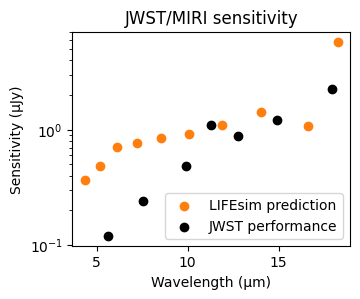

In [9]:
fig, ax = plt.subplots()
plt.scatter(spectrum[0]*1e6, s_jwst_jy*1e6, c='tab:orange', label='LIFEsim prediction')
plt.scatter(s_miri_jy[:, 0], s_miri_jy[:, 1]*1e6, c='k', label='JWST performance')
plt.xlabel('Wavelength (µm)')
plt.ylabel('Sensitivity (µJy)')

plt.legend(loc='lower right')

plt.yscale('log')
plt.title('JWST/MIRI sensitivity')

fig.savefig('/Users/fdannert/Documents/projects/InLIFEsim/working/nice_requirements/adrian_spie_24/sensitivity_jwst.pdf', bbox_inches='tight')

plt.show()


# 3. Calculation for LIFE

In [10]:
# as set in the NICE requirements document

integration_time = 4 * 24 * 60 * 60

bus.data.options.set_manual(
    spec_res=100,  # equivalent to width of F1000W filter
    diameter=3.  # equivalent to single 6.5 m mirror
)

instrument_base.apply_options()

In [11]:
fgamma_ini = (black_body(mode='planet',
                     bins=bus.data.inst['wl_bins'],
                     width=bus.data.inst['wl_bin_widths'],
                     temp=temp_p,
                     radius=radius_p,
                     distance=distance_s
                     )
          / bus.data.inst['wl_bin_widths']
          * u.photon / u.second / (u.meter ** 3))

# fgamma = np.ones_like(bus.data.inst['wl_bins']) / bus.data.inst['wl_bin_widths'] * u.photon / u.second / (u.meter ** 3)

flux_planet_spectrum = [bus.data.inst['wl_bins'] * u.meter, fgamma_ini]

In [12]:
spectrum, flux_planet, noise = instrument_base.get_spectrum(temp_s=temp_s,
                                                            radius_s=radius_s,
                                                            distance_s=distance_s,
                                                            lat_s=lat_s,
                                                            z=z,
                                                            angsep=angsep,
                                                            flux_planet_spectrum=flux_planet_spectrum,
                                                            integration_time=integration_time,
                                                            safe_mode=True) 
spectrum, fgamma, noise, flux_planet = adjust_spectrum(spectrum[1], 10, 5)

In [13]:
# setup for vega
temp = 9601 * u.K
lum = 40.12 * u.solLum
sb_constant = 5.670374419 * 10**-8 * u.W / u.m**2 / u.K**4
radius = (lum / (4 * np.pi * sb_constant * temp**4))**0.5
radius = radius.to(u.solRad).value
temp = temp.to(u.K).value
distance = 7.68

vega_spec = black_body(mode='star', 
                                   bins=np.array([bus.data.inst['wl_bins']]), 
                                 width=np.array([bus.data.inst['wl_bin_widths']]), 
                                   temp=temp, 
                                   radius=radius, 
                                   distance=distance)

mag = -2.5 * np.log10(fgamma / vega_spec)

In [14]:
s_life_jy = (fgamma / bus.data.inst['wl_bin_widths'] / u.second / (u.meter ** 3) * const.c * const.h / (bus.data.inst['wl_bins'] * u.meter)).to(u.Jy, equivalencies=u.spectral_density(bus.data.inst['wl_bins'] * u.meter))

In [18]:
np.save('/Users/fdannert/Documents/projects/InLIFEsim/working/nice_requirements/adrian_spie_24/s_life_jy.npy', s_life_jy.value[:-1])

## In magnitudes

In [127]:
s_life_jy.value[:-1]*1e6

array([0.14605763, 0.14446479, 0.1412628 , 0.13977521, 0.14053076,
       0.14107714, 0.13967291, 0.13777737, 0.13757156, 0.13979014,
       0.14113248, 0.14106807, 0.14064072, 0.14160327, 0.14425153,
       0.14720872, 0.14907781, 0.15020462, 0.15218807, 0.15596949,
       0.16086289, 0.16523623, 0.16832709, 0.17118316, 0.17545115,
       0.18166652, 0.18868284, 0.19462769, 0.19884457, 0.20266843,
       0.20798855, 0.21544103, 0.22376278, 0.23067324, 0.23498289,
       0.23783972, 0.24149947, 0.24727112, 0.25452951, 0.26111539,
       0.26502556, 0.26624115, 0.2666697 , 0.26837905, 0.27270243,
       0.2776193 , 0.28185322, 0.28390812, 0.28382023, 0.28302643,
       0.28317631, 0.28509647, 0.28847246, 0.29213881, 0.29479824,
       0.2958465 , 0.2957228 , 0.29551583, 0.29623789, 0.29831389,
       0.30146   , 0.30488433, 0.30770718, 0.30942653, 0.31016119,
       0.31051763, 0.31121334, 0.31272435, 0.31511484, 0.31806034,
       0.3210174 , 0.32347246, 0.3251681 , 0.3261965 , 0.32691

## Earth-twin @ 10 pc reference

In [162]:
print(np.sqrt(np.pi*(6.5/2)**2))
print(np.sqrt(np.pi*(3./2)**2*4))

5.760475015442927
5.317361552716548


In [156]:
temp_et = 265  # in K
radius_et = 1.  # in earth rad
distance_et = 17  # in pc

fgamma_et = (black_body(mode='planet',
                     bins=bus.data.inst['wl_bins'],
                     width=bus.data.inst['wl_bin_widths'],
                     temp=temp_et,
                     radius=radius_et,
                     distance=distance_et
                     )
          / bus.data.inst['wl_bin_widths']
          * u.photon / u.second / (u.meter ** 3))

et_jy = (fgamma_et / u.photon * const.c * const.h / (bus.data.inst['wl_bins'] * u.meter)).to(u.Jy, equivalencies=u.spectral_density(bus.data.inst['wl_bins'] * u.meter))
# et flux at 10 micron
et_jy[np.argmin(np.abs(spectrum[0]-10e-6))]

<Quantity 8.08356973e-08 Jy>

/var/folders/rs/chvp5qfj3j76n4gdp708g4vc0000gn/T/ipykernel_5379/743681971.py:25: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(minor='off', labels=['0.3', '0.5', '1'])


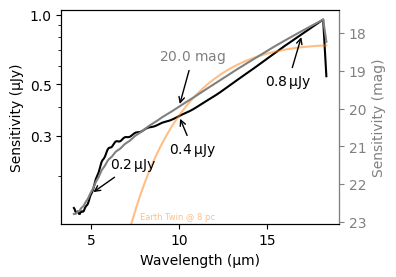

In [153]:
fig, ax = plt.subplots()

# add second y axis in jansky

ax.plot(spectrum[0][:-1]*1e6, s_life_jy.value[:-1]*1e6, c='k')

ax.set_yscale('log')

# retrieve the y axis limits
ymin, ymax = ax.get_ylim()

ax.plot(spectrum[0][:-1]*1e6, et_jy.value[:-1]*1e6, c='tab:orange', alpha=0.5)

# label the earth twin curve by putting text directly in the plot with the same color
textx = 7.3
ax.text(textx+0.5, et_jy[np.argmin(np.abs(spectrum[0]-textx*1e-6))].value*1e6, 'Earth Twin @ 8 pc', color='tab:orange', va='bottom', fontsize=6, alpha=.5)

ax.set_ylim(ymin, ymax)

ax.set_ylabel('Sensitivity (µJy)')
ax.set_xlabel('Wavelength (µm)')

ax.set_yticks([0.3, 0.5, 1])
ax.get_yaxis().set_major_formatter(ScalarFormatter())
plt.gca().set_yticklabels(minor='off', labels=['0.3', '0.5', '1'])


tax = ax.twinx()

tax.plot(spectrum[0][:-1]*1e6, mag[0][:-1], c='gray')

# invert y axis
tax.invert_yaxis()

tax.set_ylabel('Sensitivity (mag)')

# make the twin y axis gray
tax.spines['right'].set_color('gray')
tax.yaxis.label.set_color('gray')
tax.tick_params(axis='y', colors='gray')

# annotate the sensitivity at 10 µm in Jy with an arrow
ax.annotate('$' + str(np.round(s_life_jy[np.argmin(np.abs(spectrum[0]-10e-6))].value*1e6, 1)) + ' \,\mathrm{\mu}$Jy',
            xy=(10, s_life_jy[np.argmin(np.abs(spectrum[0]-10e-6))].value*1e6),
            xytext=(10, -30),  # 3 points vertical offset
            textcoords="offset points",
            ha='center', va='bottom',
            arrowprops=dict(arrowstyle='->', lw=1))

ax.annotate('$' + str(np.round(s_life_jy[np.argmin(np.abs(spectrum[0]-5e-6))].value*1e6, 1)) + ' \,\mathrm{\mu}$Jy',
            xy=(5, s_life_jy[np.argmin(np.abs(spectrum[0]-5e-6))].value*1e6),
            xytext=(30, 15),  # 3 points vertical offset
            textcoords="offset points",
            ha='center', va='bottom',
            arrowprops=dict(arrowstyle='->', lw=1))

ax.annotate('$' + str(np.round(s_life_jy[np.argmin(np.abs(spectrum[0]-17e-6))].value*1e6, 1)) + ' \,\mathrm{\mu}$Jy',
            xy=(17, s_life_jy[np.argmin(np.abs(spectrum[0]-17e-6))].value*1e6),
            xytext=(-10, -40),  # 3 points vertical offset
            textcoords="offset points",
            ha='center', va='bottom',
            arrowprops=dict(arrowstyle='->', lw=1))

# annotate the sensitivity at 10 µm in mag with an arrow
tax.annotate('$' + str(np.round(mag[0][np.argmin(np.abs(spectrum[0]-10e-6))], 1)) + '$ mag',
            xy=(10, mag[0][np.argmin(np.abs(spectrum[0]-10e-6))]),
            xytext=(10, 30),  # 3 points vertical offset
            textcoords="offset points",
            ha='center', va='bottom',
             color='gray',
            arrowprops=dict(arrowstyle='->', lw=1))

# Save the figure
fig.savefig('/Users/fdannert/Documents/projects/InLIFEsim/working/nice_requirements/adrian_spie_24/sensitivity.pdf', bbox_inches='tight')

plt.show()

In [135]:
s_life_jy[np.argmin(np.abs(spectrum[0]-1e-5))]

<Quantity 3.64259973e-07 Jy>

In [131]:
mag[0, np.argmin(np.abs(spectrum[0]-1e-5))]

19.951909528369356

# Yields

In [170]:
bus = lifesim.Bus()
bus.data.options.set_scenario('baseline')
bus.data.import_catalog(
    input_path='/Users/fdannert/Documents/projects/LIFEsim/working/requests/NICE/lifesim_runs/bryson_hab2high_500uni_3m_50res_catalog.hdf5')
bus.data.catalog.columns
# vega
temp = 9601 * u.K
lum = 40.12 * u.solLum
sb_constant = 5.670374419 * 10 ** -8 * u.W / u.m ** 2 / u.K ** 4
radius = (lum / (4 * np.pi * sb_constant * temp ** 4)) ** 0.5
radius = radius.to(u.solRad).value
temp = temp.to(u.K).value
distance = 7.68
# calculate contrast
bus.data.catalog['contrast'] = black_body(mode='planet', bins=np.array([10e-6]), width=np.array([1e-6]),
                                          temp=bus.data.catalog['temp_p'], radius=bus.data.catalog['radius_p'],
                                          distance=bus.data.catalog['distance_s']) / black_body(mode='star',
                                                                                                bins=np.array([10e-6]),
                                                                                                width=np.array([1e-6]),
                                                                                                temp=bus.data.catalog[
                                                                                                    'temp_s'],
                                                                                                radius=bus.data.catalog[
                                                                                                    'radius_s'],
                                                                                                distance=
                                                                                                bus.data.catalog[
                                                                                                    'distance_s'])

bus.data.catalog['log_flux_p'] = black_body(mode='planet', bins=np.array([10e-6]), width=np.array([1e-6]),
                                            temp=bus.data.catalog['temp_p'], radius=bus.data.catalog['radius_p'],
                                            distance=bus.data.catalog['distance_s'])

bus.data.catalog['mag_p'] = -2.5 * np.log10(
    black_body(mode='planet', bins=np.array([10e-6]), width=np.array([1e-6]), temp=bus.data.catalog['temp_p'],
               radius=bus.data.catalog['radius_p'], distance=bus.data.catalog['distance_s']) / black_body(mode='star',
                                                                                                          bins=np.array(
                                                                                                              [10e-6]),
                                                                                                          width=np.array(
                                                                                                              [1e-6]),
                                                                                                          temp=temp,
                                                                                                          radius=radius,
                                                                                                          distance=distance))

Importing Catalog...
Beginning Import...
Import completed (Time: 0.699167013168335), changing string object types...
[Done] (Time: 0.06566810607910156)


In [171]:
bus.data.catalog[np.logical_and(bus.data.catalog.habitable, bus.data.catalog.detected)]['mag_p'].min()

15.53429413610813

In [172]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

In [173]:
0.59/2*1e-5/10/np.pi*180*3600

0.06084811784289344

In [174]:
def get_detections(catalog,
                   habitable,
                   radius,
                   nuniverse,
                   sun_like=False):
    mask = np.logical_and.reduce((catalog.radius_p < radius[1],
                                    catalog.radius_p > radius[0],
                                    catalog.detected))
    
    if habitable is not None:
        mask = np.logical_and(mask, catalog[habitable])
        
    if sun_like:
        mask = np.logical_and(mask, catalog.stype != 'M')
        # mask = np.logical_and.reduce((mask, catalog.temp_s > 4800, catalog.temp_s < 6300))
    
    detections = []
    for i in range(nuniverse):
        detections.append(np.sum(np.logical_and(mask, catalog.nuniverse == i)))
    
    detections = np.array(detections)
    
    return np.quantile(detections, [0.16, 0.5, 0.84], method='linear')

In [175]:
# add habitable zones


bus.data.catalog['habitable_conservative'] = False
bus.data.catalog['habitable_optimistic'] = False

for ns in np.unique(bus.data.catalog.nstar):
    mask = bus.data.catalog.nstar == ns
    _, _, _, hz_in, hz_out, _ = single_habitable_zone(model='Kopparapu-Conservative',
                                                      temp_s=bus.data.catalog.temp_s[mask].iloc[0],
                                                      radius_s=bus.data.catalog.radius_s[mask].iloc[0])
    bus.data.catalog.loc[mask, 'habitable_conservative'] = (
        np.logical_and.reduce((bus.data.catalog.semimajor_p[mask] > hz_in,
                               bus.data.catalog.semimajor_p[mask] < hz_out,
                               bus.data.catalog.radius_p[mask] < 1.5,
                               bus.data.catalog.radius_p[mask] > 0.5)))
    
    bus.data.catalog.loc[mask, 'habitable_eec'] = (
        np.logical_and.reduce((bus.data.catalog.semimajor_p[mask] > hz_in,
                               bus.data.catalog.semimajor_p[mask] < hz_out,
                               bus.data.catalog.radius_p[mask] < 1.4,
                               bus.data.catalog.radius_p[mask] > 0.8*bus.data.catalog.radius_p[mask]*bus.data.catalog.semimajor_p[mask]**(-0.5)
                               )))
    
    _, _, _, hz_in, hz_out, _ = single_habitable_zone(model='Kopparapu-Optimistic',
                                                      temp_s=bus.data.catalog.temp_s[mask].iloc[0],
                                                      radius_s=bus.data.catalog.radius_s[mask].iloc[0])
    bus.data.catalog.loc[mask, 'habitable_optimistic'] = (
        np.logical_and.reduce((bus.data.catalog.semimajor_p[mask] > hz_in,
                               bus.data.catalog.semimajor_p[mask] < hz_out,
                               bus.data.catalog.radius_p[mask] < 1.5,
                               bus.data.catalog.radius_p[mask] > 0.5)))

In [176]:
bus.data.catalog.stype.unique()

<StringArray>
['G', 'K', 'F', 'M']
Length: 4, dtype: string

In [177]:
lims, detections = get_detections(bus.data.catalog, 'habitable_eec', [0., 50.], 500)

ValueError: too many values to unpack (expected 2)

In [178]:
plt.hist(detections, bins=20)
plt.axvline(lims[0], c='r')
plt.axvline(lims[1], c='r')
plt.axvline(lims[2], c='r')

NameError: name 'detections' is not defined

In [179]:
cats = np.array((get_detections(bus.data.catalog, None, [0.5, 1.5], 500, True),
                 get_detections(bus.data.catalog, 'habitable_optimistic', [0., 50.], 500, True),
                 get_detections(bus.data.catalog, 'habitable_conservative', [0., 50.], 500, True),
                 get_detections(bus.data.catalog, 'habitable_eec', [0., 50.], 500, True),
                 ))
print(cats)

[[28.   34.   40.  ]
 [22.   27.   32.  ]
 [12.   15.   19.  ]
 [ 6.84  9.   12.16]]


In [180]:
categories = ['Ter.\nplanets', 'Opt.\nHZ', 'Cons.\nHZ', 'EEC']

In [216]:
bar_colors

[(0.23920691667263239, 0.26230861756344964, 0.535551744864301, 1.0),
 (0.24633565834842958, 0.32872279144010896, 0.6282590930787467, 1.0),
 (0.24397378347041998, 0.403209848198766, 0.6851907482426947, 1.0),
 (0.26009231500605867, 0.4817604241612176, 0.7194288695343958, 1.0)]

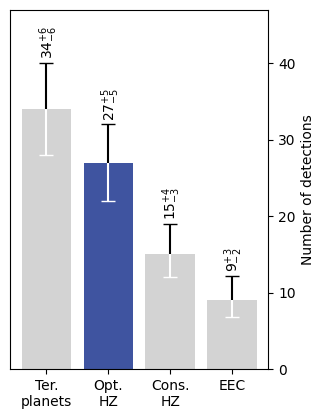

In [217]:
# Plotting
fig, ax = plt.subplots(figsize=(5/1.5, 7/1.5))

# Use the cmocean 'ice' colormap
cmap = ice

# Assign a color to each bar
bar_colors = [cmap(i) for i in np.linspace(0.3, 0.5, len(categories))]

bar_colors[0] = 'lightgray'
bar_colors[2] = 'lightgray'
bar_colors[3] = 'lightgray'

bars = ax.bar(categories, 
              cats[:, 1], 
              #yerr=np.array((cats[:, 1] - cats[:, 0], cats[:, 2] - cats[:, 1])), 
              color=bar_colors, 
              capsize=5)

# Add labels and title
ax.set_ylabel('Values')

for bar, value, err_low, err_high, color in zip(bars, cats[:, 1], cats[:, 1] - cats[:, 0], cats[:, 2] - cats[:, 1], bar_colors):
    height = bar.get_height()
    plotline1, caplines1, barlinecols1 = ax.errorbar(
        bar.get_x() + bar.get_width() / 2, height,
        yerr=[[err_low], [err_high]],
        fmt='none', color='white', markersize=5, capsize=0, uplims=True)

    caplines1[0].set_marker('_')
    caplines1[0].set_markersize(10)

    plotline2, caplines2, barlinecols2 = ax.errorbar(
        bar.get_x() + bar.get_width() / 2, height,
        yerr=[[0], [err_high]],
        fmt='none', color='k', markersize=5, capsize=0, lolims=True)
    
    caplines2[0].set_marker('_')
    caplines2[0].set_markersize(10)

for bar, value, err_low, err_high in zip(bars, cats[:, 1], cats[:, 1] - cats[:, 0], cats[:, 2] - cats[:, 1]):
    height = bar.get_height() + err_high
    ax.annotate('$' + str(int(np.round(value))) +'^{+' + str(int(np.round(err_high))) + '}_{-' + str(int(np.round(err_low))) + '}$',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(1.5, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', rotation=90)
    
plt.ylabel('Number of detections')

# ylabel right, yticks right
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()

plt.ylim(0, 47)

fig.savefig('/Users/fdannert/Documents/projects/InLIFEsim/working/nice_requirements/adrian_spie_24/yields_alt.pdf', bbox_inches='tight')
# Show plot
plt.show()

In [212]:
subsample = bus.data.catalog[bus.data.catalog.habitable_optimistic].sample(n=int(bus.data.catalog[bus.data.catalog.habitable_optimistic].shape[0]/10), replace=False, axis=0)

/Users/fdannert/Documents/projects/LIFEsim/venv_lifesim/lib/python3.8/site-packages/seaborn/axisgrid.py:2214: UserWarning: The marginal plotting function has changed to `histplot`, which does not accept the following argument(s): rug.
  warnings.warn(msg, UserWarning)
/var/folders/rs/chvp5qfj3j76n4gdp708g4vc0000gn/T/ipykernel_5379/3682680931.py:11: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  g.ax_joint.clear()
/var/folders/rs/chvp5qfj3j76n4gdp708g4vc0000gn/T/ipykernel_5379/3682680931.py:11: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  g.ax_joint.clear()
/Users/fdannert/Documents/projects/LIFEsim/venv_lifesim/lib/python3.8/site-packages/seaborn/_oldcore.py:1328: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  x_visible = any(t.get_visible() for t in ax.get_xticklabels())
/Users/fdannert/Documents/projects/LIFEsim/venv_lifesim/lib/python3.8/site-packages/seaborn/_oldco

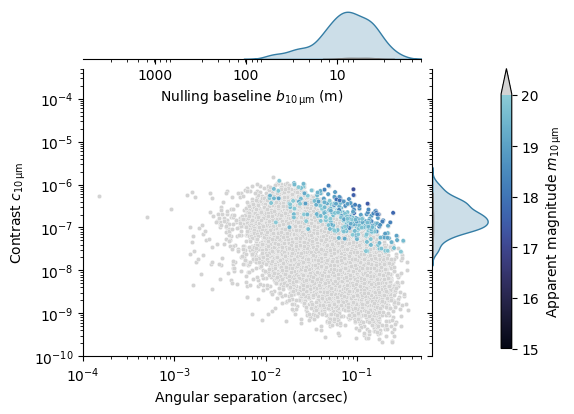

In [214]:
subsample = subsample[subsample.stype != 'M']

g = sns.jointplot(x='angsep', y='contrast', hue='habitable',
                  data=subsample[subsample.mag_p < 20],
                  palette={True: '#347DA5', False: 'gray'},
                  xlim=[1e-5, 1e0], ylim=[1e-12, 1e-1], s=10,
                  marginal_kws=dict(log_scale=True, rug=True),
                 legend=False,
                 height=5.5)

g.ax_joint.clear()

# Define the threshold values
upper_threshold = 20
lower_threshold = 15

# Create a colormap for the main data range
cmap_main = truncate_colormap(ice, 0., 0.8)

# Create a new colormap with gray below and above the thresholds
cmap = ListedColormap(list(cmap_main(np.linspace(0, 1, 258))) + ['lightgray'])

# Define the boundaries
boundaries = list(np.linspace(lower_threshold, upper_threshold, 256)) + [upper_threshold, 30]
norm = BoundaryNorm(boundaries, cmap.N)

# norm = Normalize(vmin=15, vmax=21)
g2 = sns.scatterplot(x='angsep', y='contrast', hue_norm=norm,
                  data=subsample,
                s=10,
                 legend=False,
                    ax=g.ax_joint,
                    color='lightgray')
g2 = sns.scatterplot(x='angsep', y='contrast', hue='mag_p', palette=cmap, hue_norm=norm,
                  data=subsample[np.logical_and(subsample.habitable, subsample.mag_p < 20)],
                s=10,
                 legend=False,
                    ax=g.ax_joint)


# add a colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# move the colorbar to the right
g.fig.subplots_adjust(right=0.9)
cbar_ax = g.fig.add_axes([0.92, 0.125, 0.02, 0.7])

# remove the minor ticks from the colorbar
cbar_ax.yaxis.set_tick_params(which='minor', length=0)

g.fig.colorbar(sm, cax=cbar_ax, extend='max', extendrect=False, label='Apparent magnitude $m_\mathrm{10 \, \mu m}$', extendfrac=0.1, ticks=np.arange(15, 21, 1))

g.ax_joint.set_xscale('log')
g.ax_joint.set_yscale('log')
g.ax_marg_x.set_xscale('log')
g.ax_marg_y.set_yscale('log')
g.ax_joint.set_xlabel('Angular separation (arcsec)')
g.ax_joint.set_ylabel('Contrast $c_\mathrm{10 \, \mu m}$')

# add second x axis below the existing x axis
# as @ali14 pointed out, for python3, use this
# for sp in ax2.spines.values():
# and for python2, use this


# set xlim
g.ax_joint.set_xlim([1e-4, 5e-1])
g.ax_joint.set_ylim([1e-10, 5e-4])

# make twin x axis with the same extent as the original x axis
ax2 = g.ax_joint.twiny()
ax2.set_xscale('log')
ax2.set_xlim(g.ax_joint.get_xlim())

# Move twinned axis ticks and label from top to bottom
ax2.xaxis.set_ticks_position("bottom")
ax2.xaxis.set_label_position("bottom")

# Offset the twin axis below the host
ax2.spines["bottom"].set_position(("axes", 1.035))

# Turn on the frame for the twin axis, but then hide all 
# but the bottom spine
ax2.set_frame_on(True)
ax2.patch.set_visible(False)

for sp in ax2.spines.values():
    sp.set_visible(False)
ax2.spines["bottom"].set_visible(True)

new_tick_locations = np.array([10, 100, 1000])

def tick_function(X):
    """
    Convert the nulling baseline in meters to the angular resolution in arcseconds
    :param X: 
    :return: 
    """
    V = 0.59 / 2 * 1e-5 / (X) / (np.pi / 180 / 3600)
    return V

def tick_function_invert(V):
    """
    Convert the angular resolution in arcseconds to the nulling baseline in meters
    :param V: 
    :return: 
    """
    X = 0.59 / 2 * 1e-5 / (V * np.pi / 180 / 3600)
    return X

ax2.set_xticks(tick_function(new_tick_locations))
ax2.set_xticklabels(new_tick_locations)
ax2.set_xlabel(r"Nulling baseline $b_\mathrm{10 \, \mu m}$ (m)")

# move upper part of jointplot more upwards, only the upper plot should move
# g.ax_joint.set_position([0.1, 0.1, 0.6, 0.6])
# g.ax_marg_x.set_position([0.1, 0.7, 0.6, 0.2])
# g.ax_marg_y.set_position([0.7, 0.1, 0.2, 0.6])  # [left, bottom, width, height] 

# turn off axis of the upper plot only
g.ax_marg_x.axis('off')

# adjust figsize
g.fig.set_figwidth(8/1.5)
g.fig.set_figheight(6/1.5)

# rasterize datapoints
g.ax_joint.collections[0].set_rasterized(True)

# also rasterize the blue datapoints
g.ax_joint.collections[1].set_rasterized(True)

g.savefig('/Users/fdannert/Documents/projects/InLIFEsim/working/nice_requirements/adrian_spie_24/angsep_contrast_sensitivity_FGK.pdf', dpi=300)

plt.show()

In [206]:
tick_function_invert(0.001)

608.4811784289342

/var/folders/rs/chvp5qfj3j76n4gdp708g4vc0000gn/T/ipykernel_5379/1668717111.py:8: UserWarning: Ignoring `ax`; jointplot is a figure-level function.
  g = sns.jointplot(x='angsep', y='contrast', hue='habitable',
/Users/fdannert/Documents/projects/LIFEsim/venv_lifesim/lib/python3.8/site-packages/seaborn/axisgrid.py:2214: UserWarning: The marginal plotting function has changed to `histplot`, which does not accept the following argument(s): rug.
  warnings.warn(msg, UserWarning)
/var/folders/rs/chvp5qfj3j76n4gdp708g4vc0000gn/T/ipykernel_5379/1668717111.py:16: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  g.ax_joint.clear()
/var/folders/rs/chvp5qfj3j76n4gdp708g4vc0000gn/T/ipykernel_5379/1668717111.py:16: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  g.ax_joint.clear()
/Users/fdannert/Documents/projects/LIFEsim/venv_lifesim/lib/python3.8/site-packages/seaborn/_oldcore.py:1328: UserWarning: Attempt to set non-posit

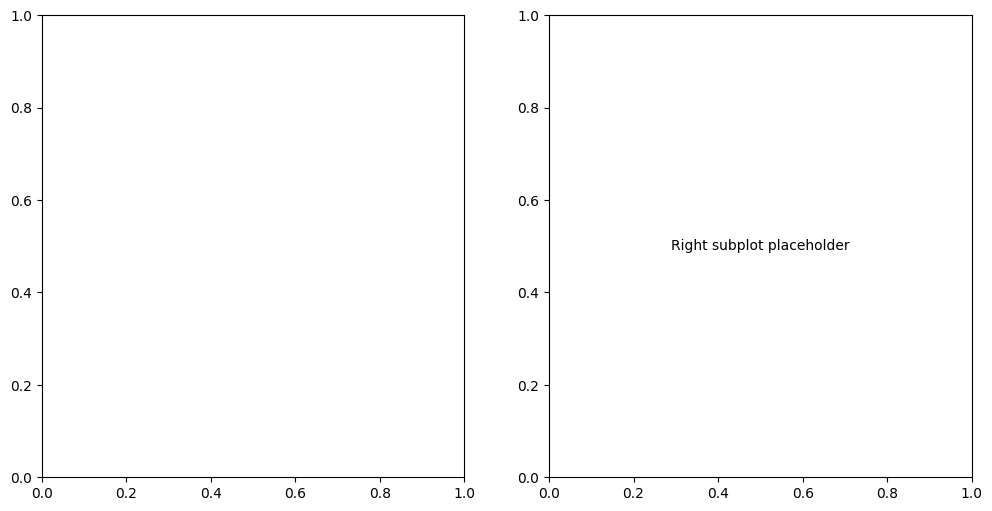

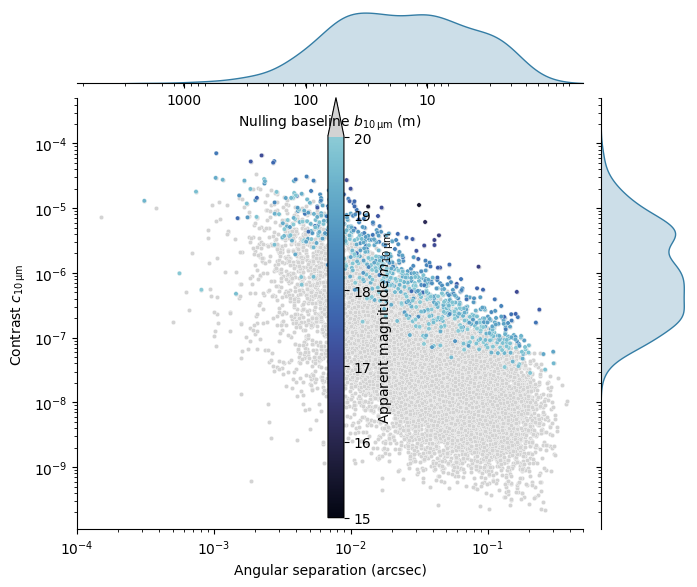

In [183]:

# Sample data from bus.data.catalog
subsample = bus.data.catalog[bus.data.catalog.habitable].sample(n=int(bus.data.catalog[bus.data.catalog.habitable].shape[0]/10), replace=False, axis=0)

# Create a new figure with a 1x2 grid of subplots
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(12, 6))  # Adjust figsize as needed

# Create the jointplot with a specific ax
g = sns.jointplot(x='angsep', y='contrast', hue='habitable',
                  data=subsample[subsample.mag_p < 20],
                  palette={True: '#347DA5', False: 'gray'},
                  xlim=[1e-5, 1e0], ylim=[1e-12, 1e-1], s=10,
                  marginal_kws=dict(log_scale=True, rug=True),
                  legend=False,
                  height=5.5, ax=ax_left)

g.ax_joint.clear()

# Define the threshold values
upper_threshold = 20
lower_threshold = 15

# Create a colormap for the main data range
cmap_main = truncate_colormap(ice, 0., 0.8)

# Create a new colormap with gray below and above the thresholds
cmap = ListedColormap(list(cmap_main(np.linspace(0, 1, 258))) + ['lightgray'])

# Define the boundaries
boundaries = list(np.linspace(lower_threshold, upper_threshold, 256)) + [upper_threshold, 30]
norm = BoundaryNorm(boundaries, cmap.N)

# Create scatter plots
sns.scatterplot(x='angsep', y='contrast', hue_norm=norm,
                data=subsample, s=10,
                legend=False, ax=g.ax_joint, color='lightgray')

sns.scatterplot(x='angsep', y='contrast', hue='mag_p', palette=cmap, hue_norm=norm,
                data=subsample[np.logical_and(subsample.habitable, subsample.mag_p < 20)],
                s=10, legend=False, ax=g.ax_joint)

# Add a colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Move the colorbar to the right of the left plot
g.fig.subplots_adjust(right=0.9)
cbar_ax = g.fig.add_axes([0.45, 0.125, 0.02, 0.7])

# Remove the minor ticks from the colorbar
cbar_ax.yaxis.set_tick_params(which='minor', length=0)

g.fig.colorbar(sm, cax=cbar_ax, extend='max', extendrect=False,
               label='Apparent magnitude $m_\mathrm{10 \, \mu m}$', extendfrac=0.1, ticks=np.arange(15, 21, 1))

# Set scales and labels
g.ax_joint.set_xscale('log')
g.ax_joint.set_yscale('log')
g.ax_marg_x.set_xscale('log')
g.ax_marg_y.set_yscale('log')
g.ax_joint.set_xlabel('Angular separation (arcsec)')
g.ax_joint.set_ylabel('Contrast $c_\mathrm{10 \, \mu m}$')

# Add second x axis below the existing x axis
ax2 = g.ax_joint.twiny()
ax2.set_xscale('log')
ax2.set_xlim(g.ax_joint.get_xlim())

# Move twinned axis ticks and label from top to bottom
ax2.xaxis.set_ticks_position("bottom")
ax2.xaxis.set_label_position("bottom")

# Offset the twin axis below the host
ax2.spines["bottom"].set_position(("axes", 1.035))

# Hide all but the bottom spine
ax2.set_frame_on(True)
ax2.patch.set_visible(False)

for sp in ax2.spines.values():
    sp.set_visible(False)
ax2.spines["bottom"].set_visible(True)

new_tick_locations = np.array([10, 100, 1000])

def tick_function(X):
    V = 0.59 / 2 * 1e-5 / (X) / (np.pi / 180 / 3600)
    return V

ax2.set_xticks(tick_function(new_tick_locations))
ax2.set_xticklabels(new_tick_locations)
ax2.set_xlabel(r"Nulling baseline $b_\mathrm{10 \, \mu m}$ (m)")

# Hide the upper plot's x-axis
g.ax_marg_x.axis('off')

# Adjust the figure size
g.fig.set_figwidth(8)
g.fig.set_figheight(6)

# Set xlim
g.ax_joint.set_xlim([1e-4, 5e-1])

# Rasterize datapoints
g.ax_joint.collections[0].set_rasterized(True)
g.ax_joint.collections[1].set_rasterized(True)

# Leave the right subplot empty or add placeholder content
ax_right.text(0.5, 0.5, 'Right subplot placeholder', ha='center', va='center')

plt.show()
